# Image Representation via 2D Gaussian Splatting

## Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import torch
from tqdm import tqdm
import cv2

In [2]:
# Set device

DEVICE = torch.device("mps" if torch.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else
                      "cpu")
print(DEVICE)

mps


## Helper functions

In [3]:
# Gaussian helper functions

def prob_init(target, lambda_init=0.3):
    """Compute Gaussian initialization probability at each pixel based on image gradient."""
    target = target.detach().cpu().numpy()
    gradx = cv2.Sobel(target, cv2.CV_32F, dx=1, dy=0, ksize=cv2.FILTER_SCHARR)
    grady = cv2.Sobel(target, cv2.CV_32F, dx=0, dy=1, ksize=cv2.FILTER_SCHARR)
    grad_mag2 = np.sum(np.square(gradx) + np.square(grady), axis=-1)
    prob = (1.-lambda_init)*grad_mag2 /np.sum(grad_mag2) + lambda_init/(target.shape[0]*target.shape[1])
    prob = torch.from_numpy(prob)
    return prob

def init_gaussians(count, target=None, domain_grid=None, lambda_init=0.3):
    """Initialize 2D Gaussians via content-aware initialization or randomly."""
    if target is not None and domain_grid is not None:
        # Content-aware initialization of positions and colors 
        with torch.no_grad():
            # Sample pixels based on P_init
            prob = prob_init(target, lambda_init=lambda_init)
            idxs_flat = torch.multinomial(torch.ravel(prob), count)
            idxs = torch.unravel_index(idxs_flat, target.shape[:2])
        params = dict(
            positions = domain_grid[idxs].clone().detach().requires_grad_().to(DEVICE),
            inv_scales = torch.full((count, 2), 1.0/0.005, requires_grad=True, device=DEVICE), # sensitive to initial scales!
            rotations = torch.zeros(count, requires_grad=True, device=DEVICE),
            colors = target[idxs].clone().detach().requires_grad_().to(DEVICE)
        )
    else:
        # Random initialization
        params = dict(
            positions = torch.rand((count, 2), requires_grad=True, device=DEVICE),
            inv_scales = torch.full((count, 2), 1.0/0.005, requires_grad=True, device=DEVICE), # sensitive to initial scales!
            rotations = torch.zeros(count, requires_grad=True, device=DEVICE),
            colors = torch.rand((count, 3), requires_grad=True, device=DEVICE),
        )
    return params

def prob_add(output, target):
    with torch.no_grad():
        diff = torch.abs(output - target)
        prob = diff / torch.sum(diff)
        return prob

def inv_covariance(inv_scale, rotation):
    """Compute inverse covariance matrix for a batch of 2D Gaussians."""
    cos = torch.cos(rotation) # (N,)
    sin = torch.sin(rotation) # (N,)
    R = torch.stack([cos,-sin,sin,cos], dim=1).reshape(-1,2,2) # (N,2,2)
    S2_inv = torch.diag_embed(torch.square(inv_scale)) # (N,2,2)
    inv_cov = torch.einsum('...ij,...jk,...lk->...il', R, S2_inv, R) # (N,2,2)
    return inv_cov

def render_gaussians(gaussians, domain_grid):
    """Rasterize a batch of 2D Gaussians."""
    # Displacements and inverse covariance
    disp_grid = domain_grid[None,...] - gaussians['positions'][:,None,None,:] # (N,H,W,2)
    inv_cov = inv_covariance(gaussians['inv_scales'], gaussians['rotations']) # (N,2,2)
    # Contribution at each pixel, for each gaussian
    exponent = torch.einsum('n...i,nij,n...j->n...', disp_grid, inv_cov, disp_grid) # (N,H,W)
    pdf = torch.exp(-0.5 * exponent) # (N,H,W)
    # Normalized weighted sum of contributions
    contribs = pdf[...,None] * gaussians['colors'][:,None,None,:] # (N,H,W,3)
    output = torch.sum(contribs, dim=0) / (torch.sum(pdf, dim=0)[...,None] + 1e-9) # (H,W,3)
    return output

In [4]:
# Loss and other metrics

def ssim(x, y):
    """Structural similarity loss."""
    x_var, x_mean = torch.var_mean(x)
    y_var, y_mean = torch.var_mean(y)
    cov = torch.mean((x - x_mean) * (y - y_mean))
    ssim = ((2.*x_mean*y_mean)*(2.*cov)) / ((x_mean**2 + y_mean**2)*(x_var + y_var))
    return 1. - ssim

def loss_fn(prediction, target, recon_type='l2', ssim_weight=0.1):
    """L1 or L2 loss with optional SSIM loss."""
    loss = torch.zeros(1, dtype=torch.float32, device=DEVICE)
    if recon_type == 'l1':
        loss += torch.nn.functional.l1_loss(prediction, target)
    elif recon_type == 'l2':
        loss += torch.nn.functional.mse_loss(prediction, target)
    else:
        ValueError("recon_type must be 'l1' or 'l2'.")
    if ssim_weight != 0:
        loss += ssim_weight * ssim(prediction, target)
    return loss

def psnr(output, target):
    """Peak signal-to-noise ratio."""
    with torch.no_grad():
        mse = torch.nn.functional.mse_loss(output, target)
        psnr = -10. * torch.log(mse)
        return psnr

## Optimization

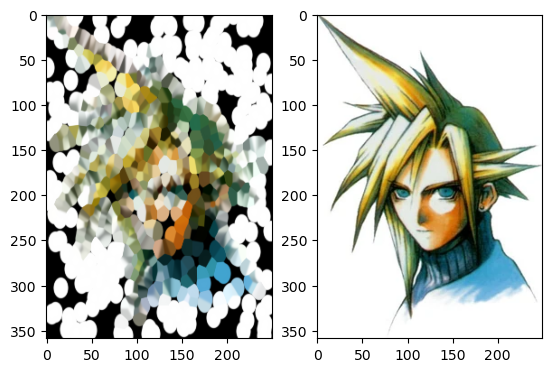

In [ ]:
# Target image
os.makedirs("data", exist_ok=True)
IMG_PATH = "data/cloud.png"
out_width = None
img = Image.open(IMG_PATH)
out_scale = min(1., out_width/img.width) if out_width else 1.
out_size = (int(img.width * out_scale), int(img.height * out_scale))
target = torch.from_numpy(np.array(img.resize(out_size), dtype=np.float32) / 255).to(DEVICE)

# Initial model and output image
domain_i, domain_j = torch.meshgrid(
    torch.linspace(0,1,target.shape[0], device=DEVICE), 
    torch.linspace(0,1,target.shape[1], device=DEVICE), indexing='ij')
domain_grid = torch.stack([domain_i, domain_j], dim=-1) # (H,W,2)
n_gaussians = 500
gaussians = init_gaussians(n_gaussians, target, domain_grid, 0.3)
# gaussians = init_gaussians(n_gaussians)
output = render_gaussians(gaussians, domain_grid)
os.makedirs("output", exist_ok=True)
plt.imsave(f"output/epoch{0:05d}.png", output.detach().cpu().numpy().clip(0,1))

# Plot initial output and target image
fig, (ax0, ax1) = plt.subplots(ncols=2)
ax0.imshow(output.detach().cpu().numpy())
ax1.imshow(target.detach().cpu().numpy())
plt.show()

Fitting image with 1000 gaussians over 1000 epochs.


100%|██████████| 1000/1000 [27:00<00:00,  1.62s/it, loss=0.026554, lr=[0.003486784401000002, 0.34867844010000015, 0.03486784401000002, 0.03486784401000002], psnr=57.8] 
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0025028787..1.0000002].


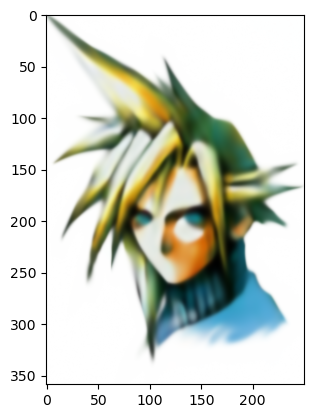

In [ ]:
# Training loop
epochs = 1000
optim_params = [
    {'params': gaussians['positions'], 'lr': 1e-2},
    {'params': gaussians['inv_scales'], 'lr': 1e0},
    {'params': gaussians['rotations'], 'lr': 1e-1},
    {'params': gaussians['colors'], 'lr': 1e-1},
]
optimizer = torch.optim.AdamW(optim_params, lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.9)

print(f"Fitting image with {len(gaussians['positions'])} gaussians over {epochs} epochs.")
logs = {'loss': [], 'psnr': []}

for epoch in (pbar := tqdm(range(epochs))):
    # Forward
    output = render_gaussians(gaussians, domain_grid)
    loss = loss_fn(output, target, recon_type='l1', ssim_weight=0.1) # Loss from Image-GS paper
    # Backward
    loss.backward()
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()
    # Clamp values to meaningful ranges
    with torch.no_grad():
        gaussians['inv_scales'].clamp_min_(0)
        gaussians['rotations'].clamp_(0,np.pi)
        gaussians['colors'].clamp_(0,1)
    # Update progress
    snr = psnr(output, target)
    pbar.set_postfix(dict(loss=f"{loss.item():.6f}", lr=scheduler.get_last_lr(), psnr=snr.item()))
    logs['loss'].append(loss.item())
    logs['psnr'].append(snr.item())
    # Save current output
    if (epoch+1) % 50 == 0:
        plt.imsave(f"output/epoch{epoch+1:05d}.png", output.detach().cpu().numpy().clip(0,1))

# Plot final output and target image
fig, (ax0, ax1) = plt.subplots(ncols=2)
ax0.imshow(output.detach().cpu().numpy())
ax1.imshow(target.detach().cpu().numpy())
plt.show()

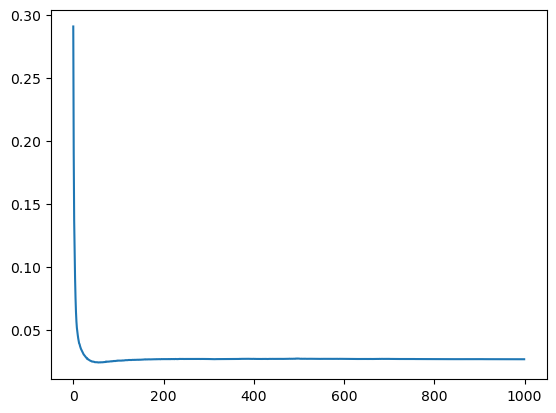

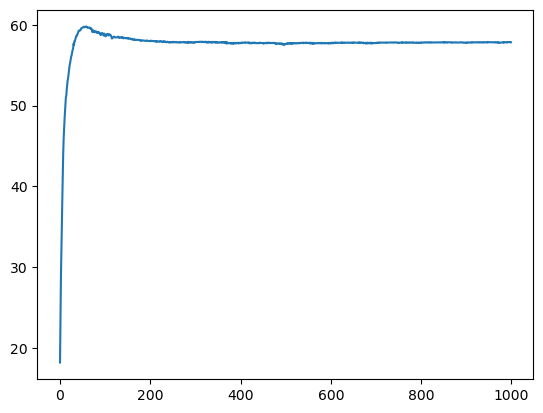

In [ ]:
# Loss and PSNR curves

plt.plot(logs['loss'])
plt.show()
plt.plot(logs['psnr'])
plt.show()